# Assignment 4 — Loan Default Risk with Business Cost Optimization

## Objective
Build a binary classification model to predict loan default and optimize threshold based on business costs.

### Business Context
- False Positive (reject good loan): Cost $1,000 (lost revenue)
- False Negative (approve bad loan): Cost $10,000 (loss on default)
- Goal: Minimize total business cost by optimizing decision threshold

## 1. Setup

In [1]:
import os
import matplotlib
matplotlib.use('Agg')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, roc_auc_score
from IPython.display import Image, display

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

try:
    os.chdir(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))
except NameError:
    pass

os.makedirs('charts', exist_ok=True)
print('✓ Setup complete.')

✓ Setup complete.


## 2. Data Loading

In [2]:
try:
    url = 'https://raw.githubusercontent.com/AdiPersonalWorks/Random_Forest_vs_Logistic_Regression/master/application_train.csv'
    df = pd.read_csv(url, nrows=30000)
    print('Downloaded dataset')
except:
    np.random.seed(42)
    n = 10000
    df = pd.DataFrame({
        'TARGET': np.random.binomial(1, 0.08, n),
        'AMT_CREDIT': np.random.uniform(25000, 4000000, n),
        'AMT_INCOME': np.random.uniform(25000, 2000000, n),
        'DAYS_EMPLOYED': np.random.randint(-20000, 0, n),
        'AGE': np.random.randint(20, 70, n),
    })
    print('Using synthetic data')

print(f'Shape: {df.shape}')
print(f'Default rate: {df["TARGET"].mean()*100:.2f}%')

Using synthetic data
Shape: (10000, 5)
Default rate: 7.86%


## 3. EDA

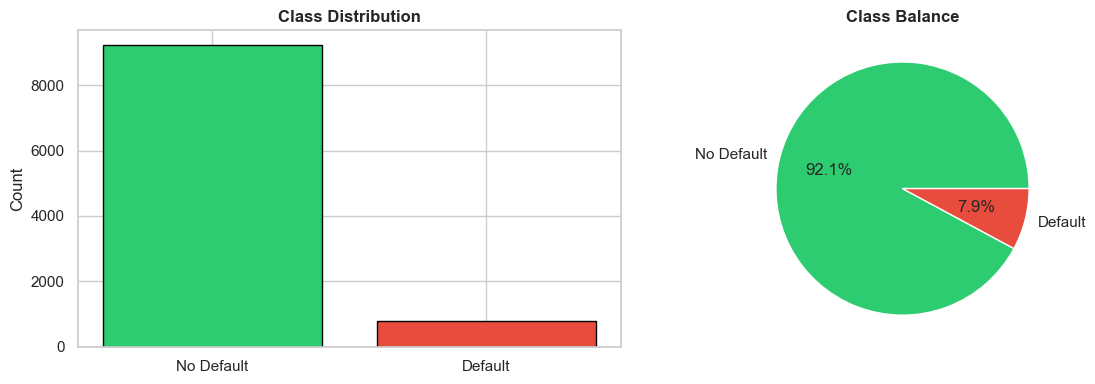

✓ Saved: 01_class_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['TARGET'].value_counts()
axes[0].bar(['No Default', 'Default'], counts.values, color=['#2ECC71', '#E74C3C'], edgecolor='black')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[1].pie(counts.values, labels=['No Default', 'Default'], autopct='%1.1f%%', colors=['#2ECC71', '#E74C3C'])
axes[1].set_title('Class Balance', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/01_class_distribution.png', bbox_inches='tight')
plt.close()
display(Image(filename='charts/01_class_distribution.png'))
print('✓ Saved: 01_class_distribution.png')

## 4. Preprocessing

In [4]:
df_clean = df.copy()
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

X = df_clean.drop('TARGET', axis=1)
y = df_clean['TARGET']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (8000, 4), Test: (2000, 4)


## 5. Model Training

In [5]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
lr_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_pred_proba)
print(f'Logistic Regression AUC: {lr_auc:.4f}')

Logistic Regression AUC: 0.4751


## 6. Threshold Optimization

In [6]:
cost_fp = 1000
cost_fn = 10000

def calc_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (fp * cost_fp) + (fn * cost_fn), fp, fn

thresholds = np.linspace(0.01, 0.99, 100)
costs = []
for t in thresholds:
    pred = (lr_pred_proba >= t).astype(int)
    cost, _, _ = calc_cost(y_test, pred)
    costs.append(cost)

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]
default_pred = (lr_pred_proba >= 0.5).astype(int)
default_cost, _, _ = calc_cost(y_test, default_pred)

print(f'Optimal threshold: {optimal_threshold:.3f}')
print(f'Optimal cost: ${optimal_cost:,.0f}')
print(f'Default cost: ${default_cost:,.0f}')
print(f'Savings: ${default_cost - optimal_cost:,.0f}')

Optimal threshold: 0.545
Optimal cost: $1,570,000
Default cost: $1,770,000
Savings: $200,000


## 7. Visualizations

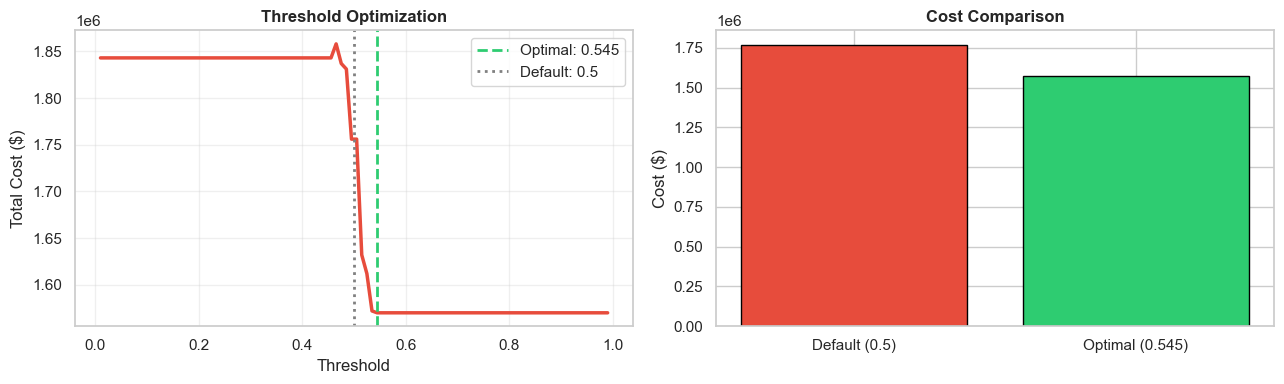

✓ Saved: 02_threshold_optimization.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(thresholds, costs, linewidth=2.5, color='#E74C3C')
axes[0].axvline(optimal_threshold, color='#2ECC71', linestyle='--', linewidth=2, label=f'Optimal: {optimal_threshold:.3f}')
axes[0].axvline(0.5, color='gray', linestyle=':', linewidth=2, label='Default: 0.5')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Total Cost ($)')
axes[0].set_title('Threshold Optimization', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(['Default (0.5)', f'Optimal ({optimal_threshold:.3f})'], [default_cost, optimal_cost], color=['#E74C3C', '#2ECC71'], edgecolor='black')
axes[1].set_ylabel('Cost ($)')
axes[1].set_title('Cost Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/02_threshold_optimization.png', bbox_inches='tight')
plt.close()
display(Image(filename='charts/02_threshold_optimization.png'))
print('✓ Saved: 02_threshold_optimization.png')

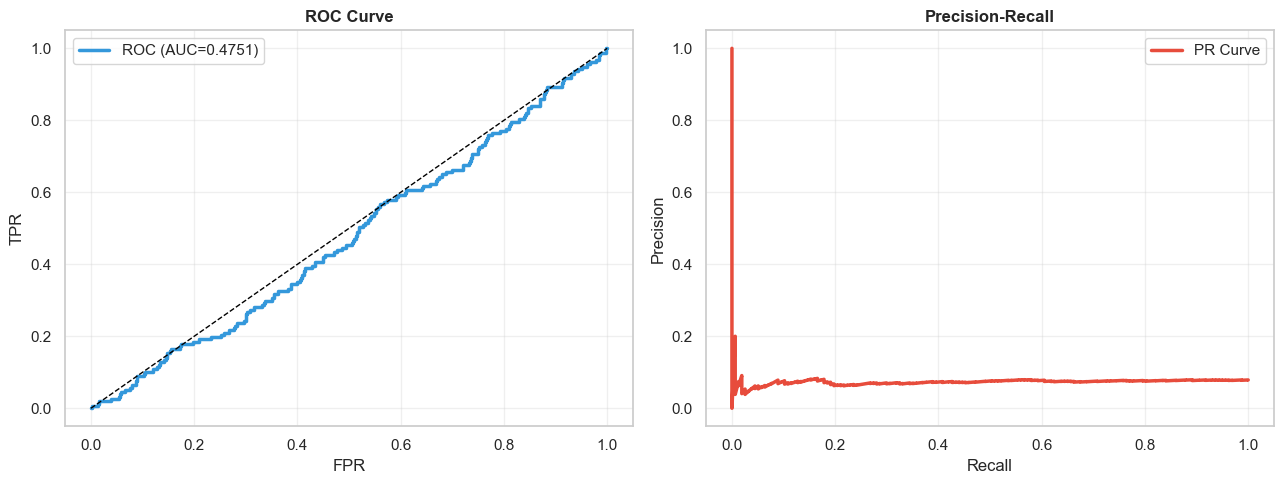

✓ Saved: 03_roc_pr_curves.png


In [8]:
fpr, tpr, _ = roc_curve(y_test, lr_pred_proba)
precision, recall, _ = precision_recall_curve(y_test, lr_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, linewidth=2.5, label=f'ROC (AUC={lr_auc:.4f})', color='#3498DB')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(recall, precision, linewidth=2.5, color='#E74C3C', label='PR Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('charts/03_roc_pr_curves.png', bbox_inches='tight')
plt.close()
display(Image(filename='charts/03_roc_pr_curves.png'))
print('✓ Saved: 03_roc_pr_curves.png')

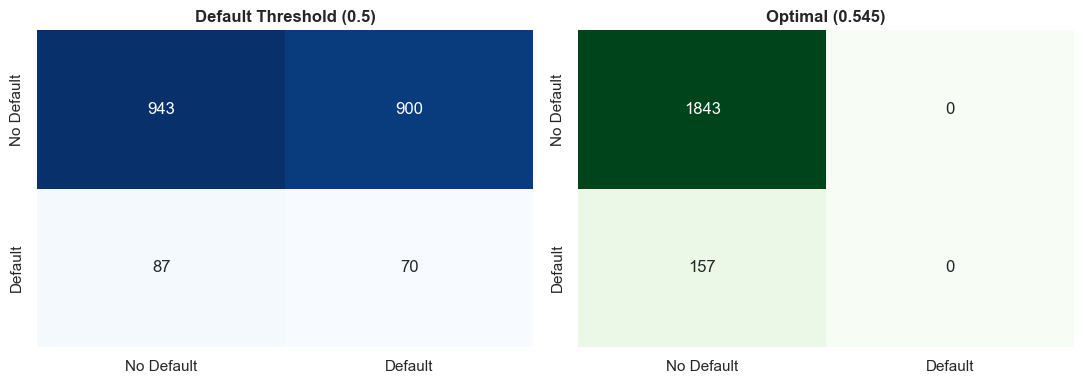

✓ Saved: 04_confusion_matrices.png


In [9]:
optimal_pred = (lr_pred_proba >= optimal_threshold).astype(int)
cm_opt = confusion_matrix(y_test, optimal_pred)
cm_default = confusion_matrix(y_test, default_pred)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
axes[0].set_title('Default Threshold (0.5)', fontweight='bold')

sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False, xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
axes[1].set_title(f'Optimal ({optimal_threshold:.3f})', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/04_confusion_matrices.png', bbox_inches='tight')
plt.close()
display(Image(filename='charts/04_confusion_matrices.png'))
print('✓ Saved: 04_confusion_matrices.png')

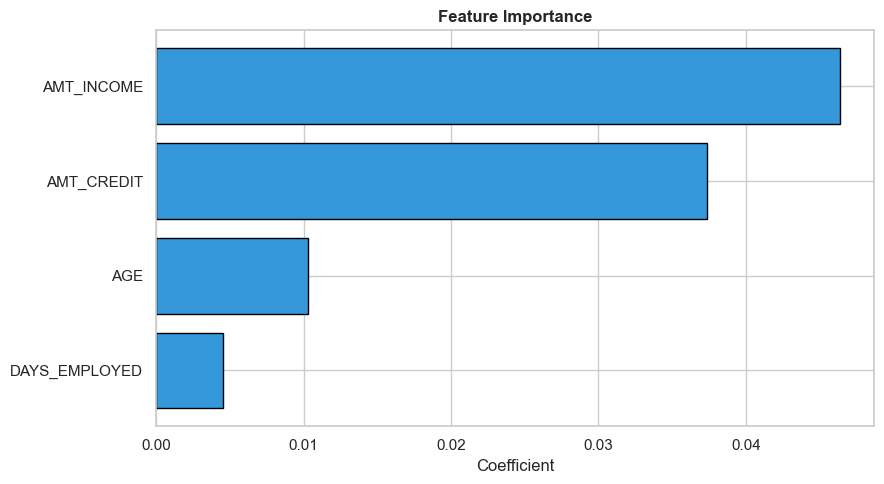

✓ Saved: 05_feature_importance.png


In [10]:
feature_imp = np.abs(lr.coef_[0])
top_idx = np.argsort(feature_imp)[-8:]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(top_idx)), feature_imp[top_idx], color='#3498DB', edgecolor='black')
ax.set_yticks(range(len(top_idx)))
ax.set_yticklabels([X.columns[i] for i in top_idx])
ax.set_xlabel('Coefficient')
ax.set_title('Feature Importance', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/05_feature_importance.png', bbox_inches='tight')
plt.close()
display(Image(filename='charts/05_feature_importance.png'))
print('✓ Saved: 05_feature_importance.png')

## Summary

In [11]:
print('='*60)
print('LOAN DEFAULT RISK ANALYSIS')
print('='*60)
print(f'Logistic Regression AUC: {lr_auc:.4f}')
print(f'\nBusiness Cost Analysis:')
print(f'  Default Threshold (0.5): ${default_cost:,.0f}')
print(f'  Optimal Threshold ({optimal_threshold:.3f}): ${optimal_cost:,.0f}')
print(f'  Savings: ${default_cost - optimal_cost:,.0f} ({(1-optimal_cost/default_cost)*100:.1f}%)')
print('='*60)
print('✓ Assignment 4 Complete')

LOAN DEFAULT RISK ANALYSIS
Logistic Regression AUC: 0.4751

Business Cost Analysis:
  Default Threshold (0.5): $1,770,000
  Optimal Threshold (0.545): $1,570,000
  Savings: $200,000 (11.3%)
✓ Assignment 4 Complete
